In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
data = pd.read_csv("student_placement_1000.csv")

print(data.head(5))



   StudentID  CGPA  AptitudeScore  Placed
0        522  3.43             85       1
1        738  3.43             71       1
2        741  3.49             79       1
3        661  2.85             91       1
4        412  2.35             57       0


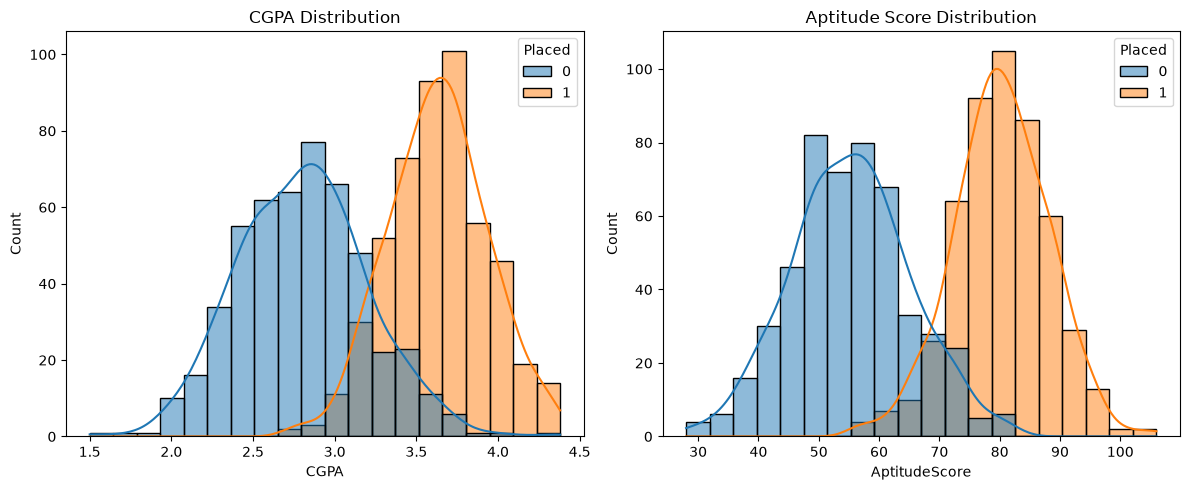

In [3]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.histplot(
    data=data,
    x="CGPA",
    hue="Placed",
    kde=True,
    bins=20
)

plt.title("CGPA Distribution")


plt.subplot(1,2,2)

sns.histplot(
    data=data,
    x="AptitudeScore",
    hue="Placed",
    kde=True,
    bins=20
)

plt.title("Aptitude Score Distribution")

plt.tight_layout()
plt.show()

In [4]:

X = data[["CGPA", "AptitudeScore"]]
y = data["Placed"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
gnb = GaussianNB()

gnb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[400.,400.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,2.341e-07
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['CGPA','AptitudeScore']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 2)","[[ 2.8 ,55.43], [ 3.63,80.16]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 2)","[[ 0.16,99.11], [ 0.1 ,63.29]]"


In [6]:

y_pred = gnb.predict(X_test)



accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy*100:.2f}%")


Accuracy: 98.00%


In [ ]:



cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)



print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[98  2]
 [ 2 98]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       100
           1       0.98      0.98      0.98       100

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



c:\Users\umar.alam\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


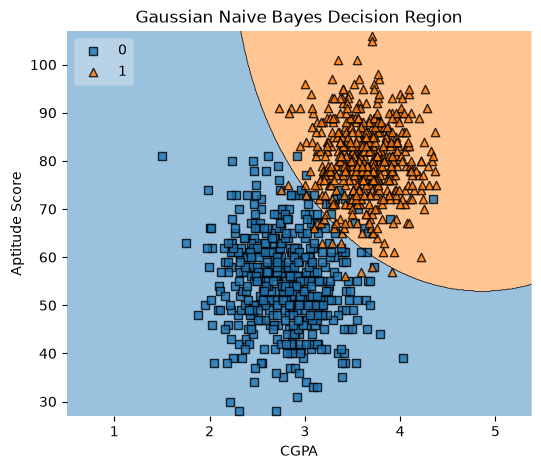

In [9]:

from mlxtend.plotting import plot_decision_regions



# Decision Region Plot
plt.figure(figsize=(6,5))

plot_decision_regions(
    X.to_numpy(),
    y.to_numpy(),
    clf=gnb,
    legend=2
)

plt.xlabel("CGPA")
plt.ylabel("Aptitude Score")
plt.title("Gaussian Naive Bayes Decision Region")

plt.show()

In [17]:
new_student = [[3.41, 70]]

prediction = gnb.predict(new_student)

print(prediction)

[1]


c:\Users\umar.alam\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
